## Module_3: Interpolation

## Team Members:
Vish Ramineni and Kiran Spencer

## Project Title:
Interpolation based on Image Analysis of Mouse Fibrotic Lung Tissue


## Project Goal:
This project seeks to use image analysis and interpolation methods to develop an algorithm that can be used in predicting fibrotic tissue concentration at different depths of the lungs in order to help a medical device company develop a lung biospy device using our image analysis pipeline.

## AI Use Statemet

Generative AI was used in this project to optimize code used for image analysis

## Disease Background: Lung Fibrosis
*Fill in information and please note that this module is truncated and only has 5 bullets (instead of the 11 that you did for Module #1).*

* Prevalence & incidence
    - Incidence: 50,000 new cases are diagnosed annually
    - Prevalence: Currently, 250,000 Americans are suffering from lung fibrosis (1)
* Risk factors (genetic, lifestyle)
    - Age: much more common in older adults, especially those over the age of 60
    - Men are diagnosed at higher rates than women
    - Genetically, 20% of people with the disease have had another family member with a type of lung disease
    - Daily life habits such as smoking and inhilation of inorganic dusts
    - Autoimmune diseases increase the chances of scarring in the lungs (5)
* Symptoms
    - Shortness of breath (dyspnea)
    - Perisistent non-productive cough
    - Fatigue
    - Aching Muscle and Joints
    - Rapid, shallow breathing (1)
* Standard of care treatment(s)
    - Antifibrotics medicinal treatment, which includes Jascayd which is a PDE4B inhibitor that lends antifibrotic and immunomodulatory effects
    - Inhaled therapies, which inlcudes Treprostinil which is specficially for those who develope pulmonary hypertension associated with the disease
    - Supplemental Oxygen and pulmonary rehabilitation are also viable methods to help patients adjust to life with the disease. 
    - In extreme cases, lung transplantation may be necessary (1)
* Biological mechanisms (anatomy, organ physiology, cell & molecular physiology)
    - Primarily affects the interstitium, which is the microscopic space betweeen the air sacs and the blood vessels. In a healthy lung, this space is less than 1 micrometer thick, promoting gas exchange. In the diseased state, this distance gets increased, hurting gas exchange. 
    - The process starts with repeated injury to Type 2 Alveolar Epithelial cells which manage lung repair and surfactant production. They start secreting pro-fibrotic signals. Then fibroblasts turn into myofibroblasts, secreting excessive collagen and causing the fibrosis. 
    - The TGF-B cytokine binds to cell surface receptors, which directly turns on the genese for collagen production and myofibroblast differentiation. (6)
* Diagnosis
    - To diagnose pulmonary fibrosis, a doctor will take a number of imaging and testing procedures to get a definitive answer. This includes a chest x-ray, CT scan, lung function tests, blood tests including arterial blood gas, bronchoscopy and maybe even a biopsy (1, 4). On top of that, providers may use an echocardiogram to rule out any heart issues. Providers will also listen to your lungs for any abnormal sounds. Through these methods the provider is able to gather sufficient evidence to diagnose pulmonary fibrosis. 
* Clinical Trials/Next-gen therapies
    - Nirandomilast from boehringer-ingelheim has just gained FDA approval for treatment for the disease in adult patients. It works by preferentially inhibiting PDE4B. The drug successfully made it through clinical trials (3). PDE4B is a key enzyme in the development of lung fibrosis and inflammation. By inhibiting this enzyme, fibrosis activity is reduced (2). This method also works better than previous drugs that inhibited the whole spectrum of PDE4 enzymes, which causes unwanted side effects. 


## Data-Set: 

"Unpublished data was collected by the Peirce-Cottler Lab (Dept. of Biomedical Engineering) and Kim Lab (Division of Pulmonary and Critical Care) at the University of Virginia School of Medicine. 

Also, since we covered this in Lecture 1 of this Module in detail, describe how the data was collected -- What techniques were used? What units are the data measured in? Etc.*

Bleomycin, a drug primarily used in chemotherapy, was used to induce lung fibrosis into otherwise healthy mice. After 3 weeks, the mice's lungs were harvested and fixed with paraformaldehyde. They were then mounted in gel, and sliced using a cryotome or microtome. These slices were then placed inside a microscope slide, and "immuno-stained" with a fluorescent antibody that binds to the protein of interest. Three proteins were stained: desmin, smooth muscle alpha actinin, and CD-31. Desmin indicates myofibroblast activity, smooth muscle alpha actinin indicates large blood vessel smooth muscle cells, and CD-31 indicates endothelial cells in all blood vessels, including capillaries. The protein of interest for us is desmin, as corresponds to the myofibroblasts, cells that fibrotic scar tissue and form lesions. The slices with desmin signals were then converted into black and white images across 78 different depths of fibrotic lung tissue. White portions of the image represent fibrotic lesions and scarring, while black portions of the image represent healthy lung. Image analysis was run to find the percent of the image that was white, indicating a relative number of the fibrotic lesions present in that layer of tissue.


## Data Analyis: 
*Describe how you analyzed the data. This is where you should intersperse your Python code so that anyone reading this Jupyter notebook can run your code to perform the analysis that you did, generate your figures, generate your .csv file, etc.). Show your graphs here, which should have proper labeles (e.g., x- and y-axes labels). Each graph you present should be thoroughly described by a caption so reader understands the data, why you are presenting it, and the main conclusion fromt the data.*

### Image Analysis

First, we analyzed 11 slices for percentage of white pixels at varying depths to create the intital baseline for interpolation. The code also returns a csv file with the slice accompanied by its percentage of white pixels. 

In [ ]:
import cv2 # Imports the OpenCV library for image processing
import pandas as pd # Imports the Pandas library for data manipulation and analysis
from termcolor import colored # Imports the termcolor library for colored terminal output
import matplotlib.pyplot as plt # Imports the Matplotlib library for plotting and visualization
from scipy.interpolate import interp1d # Imports the interp1d function from the SciPy library for interpolation
import numpy as np # Imports the NumPy library for numerical operations


# 1. Configuration: Keep data organized together
data_input = {
    "filenames": [
        r"/Users/vasishtramineni/Downloads/Computational BME/Module-3-Fibrosis/images/MASK_Sk658 Llobe ch010067.jpg",
        r"/Users/vasishtramineni/Downloads/Computational BME/Module-3-Fibrosis/images/MASK_SK658 Slobe ch010107.jpg",
        r"/Users/vasishtramineni/Downloads/Computational BME/Module-3-Fibrosis/images/MASK_SK658 Slobe ch010087.jpg",
        r"/Users/vasishtramineni/Downloads/Computational BME/Module-3-Fibrosis/images/MASK_Sk658 Llobe ch010019.jpg",
        r"/Users/vasishtramineni/Downloads/Computational BME/Module-3-Fibrosis/images/MASK_Sk658 Llobe ch010051.jpg",
        r"/Users/vasishtramineni/Downloads/Computational BME/Module-3-Fibrosis/images/MASK_SK658 Slobe ch010104.jpg",
        r"/Users/vasishtramineni/Downloads/Computational BME/Module-3-Fibrosis/images/MASK_SK658 Slobe ch010103.jpg",
        r"/Users/vasishtramineni/Downloads/Computational BME/Module-3-Fibrosis/images/MASK_SK658 Slobe ch010068.jpg",
        r"/Users/vasishtramineni/Downloads/Computational BME/Module-3-Fibrosis/images/MASK_SK658 Slobe ch010118.jpg",
        r"/Users/vasishtramineni/Downloads/Computational BME/Module-3-Fibrosis/images/MASK_SK658 Slobe ch010098.jpg",
        r"/Users/vasishtramineni/Downloads/Computational BME/Module-3-Fibrosis/images/MASK_SK658 Slobe ch010136.jpg"
        

    ],
    "depths": [1500, 6300, 8000, 60, 400, 9700,9600,9800,9900,10000,9200] # Depths corresponding to each image in microns
}

results = [] # Initialize an empty list to store results for each image

print(colored("Processing images...", "yellow"))

# 2. Single-pass loop: Load, Process, and Collect data in one go
for filepath, depth in zip(data_input["filenames"], data_input["depths"]): # Loop through each file and its corresponding depth
    # Load image in grayscale and process immediately
    img = cv2.imread(filepath, cv2.IMREAD_GRAYSCALE)
    if img is None:
        print(colored(f"Error: Could not load {filepath}", "red"))
        continue

    # OpenCV countNonZero is faster than numpy sum for binary images
    _, binary = cv2.threshold(img, 127, 255, cv2.THRESH_BINARY) # Convert to binary (0 and 255)
    white_count = cv2.countNonZero(binary) # Count white pixels (255)
    total_pixels = binary.size # Total number of pixels in the image
    black_count = total_pixels - white_count # Calculate black pixels by subtracting white from total
    white_percent = (white_count / total_pixels) * 100 # Calculate percentage of white pixels

    # Store results in a list of dictionaries (optimal for Pandas)
    results.append({
        "Filenames": filepath,
        "Depths": depth,
        "White_Count": white_count,
        "Black_Count": black_count,
        "White percents": white_percent
    }) # Append the results for the current image to the results list

# 3. Output results (Printing and CSV)
print(colored("\nCounts of pixel by color in each image", "yellow")) # Print a header for the output section
for i, res in enumerate(results): # Loop through the results and print the counts and percentages for each image
    print(colored(f"White pixels in image {i}: {res['White_Count']}", "white"))
    print(colored(f"Black pixels in image {i}: {res['Black_Count']}", "white"))
    print(colored(f"{res['Filenames']}:", "red"))
    print(f"{res['White percents']:.4f}% White | Depth: {res['Depths']} microns\n")

# Create DataFrame and save
df = pd.DataFrame(results) 
df[['Filenames', 'Depths', 'White percents']].to_csv('Percent_White_Pixels.csv', index=False) # Save the relevant columns to a CSV file

print("The .csv file 'Percent_White_Pixels.csv' has been created.")

df # Display the DataFrame to verify the results


# Used Gemini for help in optimizing the code and making it more efficient.

Processing images...

Counts of pixel by color in each image
White pixels in image 0: 62508
Black pixels in image 0: 4131796
/Users/vasishtramineni/Downloads/Computational BME/Module-3-Fibrosis/images/MASK_Sk658 Llobe ch010067.jpg:
1.4903% White | Depth: 1500 microns

White pixels in image 1: 100236
Black pixels in image 1: 4094068
/Users/vasishtramineni/Downloads/Computational BME/Module-3-Fibrosis/images/MASK_SK658 Slobe ch010107.jpg:
2.3898% White | Depth: 6300 microns

White pixels in image 2: 155019
Black pixels in image 2: 4039285
/Users/vasishtramineni/Downloads/Computational BME/Module-3-Fibrosis/images/MASK_SK658 Slobe ch010087.jpg:
3.6959% White | Depth: 8000 microns

White pixels in image 3: 31331
Black pixels in image 3: 4162973
/Users/vasishtramineni/Downloads/Computational BME/Module-3-Fibrosis/images/MASK_Sk658 Llobe ch010019.jpg:
0.7470% White | Depth: 60 microns

White pixels in image 4: 43424
Black pixels in image 4: 4150880
/Users/vasishtramineni/Downloads/Computatio

,Filenames,Depths,White_Count,Black_Count,White percents
0,/Users/vasishtramineni/Downloads/Computational...,1500,62508,4131796,1.490307
1,/Users/vasishtramineni/Downloads/Computational...,6300,100236,4094068,2.389812
2,/Users/vasishtramineni/Downloads/Computational...,8000,155019,4039285,3.695941
3,/Users/vasishtramineni/Downloads/Computational...,60,31331,4162973,0.746989
4,/Users/vasishtramineni/Downloads/Computational...,400,43424,4150880,1.035309
5,/Users/vasishtramineni/Downloads/Computational...,9700,203857,3990447,4.860330
6,/Users/vasishtramineni/Downloads/Computational...,9600,193743,4000561,4.619193
7,/Users/vasishtramineni/Downloads/Computational...,9800,214773,3979531,5.120587
8,/Users/vasishtramineni/Downloads/Computational...,9900,237289,3957015,5.657411
9,/Users/vasishtramineni/Downloads/Computational...,10000,383479,3810825,9.142852


The resultant white percent at respective depths is shown above. We then developed an interpolation algorithm and interpolated 3 depths, 4500 microns, 7000 microns, and 9400 mircons using our initial 11 slices as the initial parameters. For each depth, we interpolated linearly and quadratically. Linear uses 2 local points to estimate the point in between while quadratic uses 3 local points to estimate in between. We intentionally had picked points to interpolate that had varying degrees of nearby actual data to base the interpolation estimate off of. For example, there was minimal data in the 4500 micron region as compared to the moderately populated region around 7000 microns and the heavily populated region around 9500 microns to compare the effects of point spacing against interpolation accuracy.

### Linear Interpolation

The code and outputs for the linear interpolation is below. When run, the code asks for depths to interpolate at, and then to type "done" when finished. We used this code to do a linear interpolation at 4500, 7000, and 9400 microns.

Enter depths to interpolate. Type 'done' when finished.
Interpolated point: x = 4500.0, y = 2.0525
Interpolated point: x = 7000.0, y = 2.9276
Interpolated point: x = 9400.0, y = 4.2603


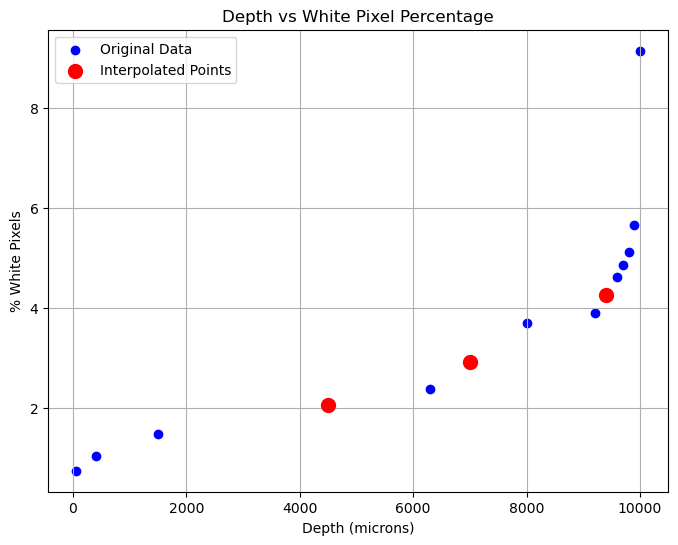

In [ ]:
# Interpolate multiple points: given depths, find corresponding white pixel percentages

# 1. Pull the full lists from DataFrame
x = df['Depths'].values # Get the 'Depths' column as a NumPy array for interpolation
y = df['White percents'].values # Get the 'White percents' column as a NumPy array for interpolation

# 2. Sort data for interpolation
sort_idx = np.argsort(x)
x_sorted = x[sort_idx] # Sort the depths in ascending order for interpolation
y_sorted = y[sort_idx] # Sort the corresponding white pixel percentages according to the sorted depths

# 3. Create interpolation function
i = interp1d(x_sorted, y_sorted, kind='linear', fill_value="extrapolate") # Create a linear interpolation function based on the sorted data, allowing for extrapolation outside the original range

# 4. Repeatedly ask for depths
interpolated_depths = [] # Initialize an empty list to store user-input depths for interpolation
interpolated_points = [] # Initialize an empty list to store the corresponding interpolated white pixel percentages

print(colored("Enter depths to interpolate. Type 'done' when finished.", "yellow"))

while True:
    user_input = input(colored(
        "Enter a depth in microns (or type 'done'): ", "yellow"
    ))
    
    if user_input.lower() == 'done':
        break
    
    try:
        interpolate_depth = float(user_input) # Convert user input to a float for interpolation
        interpolate_point = float(i(interpolate_depth)) # Use the interpolation function to find the corresponding white pixel percentage for the input depth
        
        interpolated_depths.append(interpolate_depth) # Append the input depth to the list of interpolated depths
        interpolated_points.append(interpolate_point) # Append the interpolated white pixel percentage to the list of interpolated points
        
        print(colored(
            f"Interpolated point: x = {interpolate_depth}, y = {interpolate_point:.4f}", 
            "green"
        ))
    except ValueError:
        print(colored("Please enter a valid number or 'done'.", "red"))

# --- Plotting ---
plt.figure(figsize=(8, 6))

# Original data
plt.scatter(x, y, color='blue', label='Original Data') # Plot the original data points (depths vs white pixel percentages) in blue

# Interpolated points
if len(interpolated_depths) > 0:
    plt.scatter(interpolated_depths, interpolated_points,
                color='red', s=100, label='Interpolated Points', zorder=5) # Plot the user-input interpolated points in red with larger size for visibility

plt.title('Depth vs White Pixel Percentage') # Set the title of the plot
plt.xlabel('Depth (microns)') # Set the label for the x-axis
plt.ylabel('% White Pixels') # Set the label for the y-axis
plt.legend() # Display the legend
plt.grid(True) # Display a grid
plt.show() # Show the plot

Based on the linear interpolation, the estimated white percent at 4500 microns is 2.0525, the estimated white percent at 7000 microns is 2.9276, and the estimated white percent at 9400 microns is 4.2603. These estimates appear to fit the general trend of the other points, with fibrosis increasing with depth into the lung.

### Quadratic Interpolation

The code and outputs for the quadratic interpolation is below. When run, the code asks for depths to interpolate at, and then to type "done" when finished. We used this code to do a quadratic interpolation at 4500, 7000, and 9400 microns.

Enter depths to interpolate. Type 'done' when finished.
Interpolated point: x = 4500.0, y = 1.6317
Interpolated point: x = 7000.0, y = 3.0035
Interpolated point: x = 9400.0, y = 4.2108


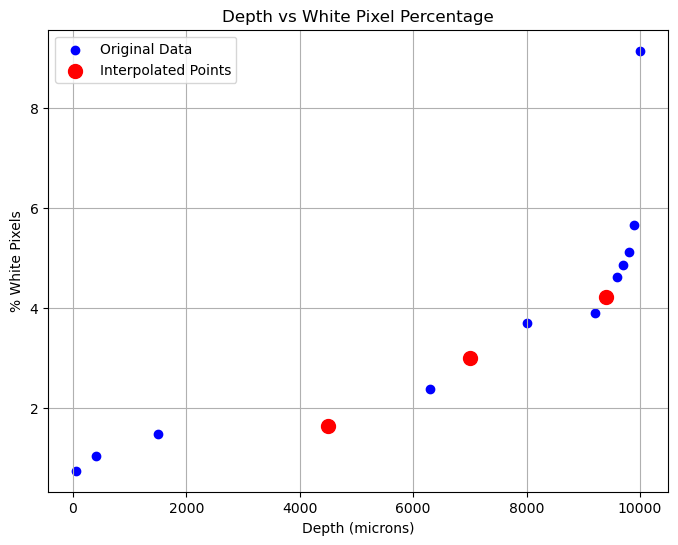

In [ ]:
# Interpolate multiple points: given depths, find corresponding white pixel percentages

# 1. Pull the full lists from your DataFrame
x = df['Depths'].values # Get the 'Depths' column as a NumPy array for interpolation
y = df['White percents'].values # Get the 'White percents' column as a NumPy array for interpolation

# 2. Sort data for interpolation
sort_idx = np.argsort(x)
x_sorted = x[sort_idx] # Sort the depths in ascending order for interpolation
y_sorted = y[sort_idx] # Sort the corresponding white pixel percentages according to the sorted depths

# 3. Create interpolation function
i = interp1d(x_sorted, y_sorted, kind='quadratic', fill_value="extrapolate") # Create a quadratic interpolation function based on the sorted data, allowing for extrapolation outside the original range

# 4. Repeatedly ask for depths
interpolated_depths = [] # Initialize an empty list to store user-input depths for interpolation
interpolated_points = [] # Initialize an empty list to store the corresponding interpolated white pixel percentages

print(colored("Enter depths to interpolate. Type 'done' when finished.", "yellow"))

while True:
    user_input = input(colored(
        "Enter a depth in microns (or type 'done'): ", "yellow"
    ))
    
    if user_input.lower() == 'done':
        break
    
    try:
        interpolate_depth = float(user_input) # Convert user input to a float for interpolation
        interpolate_point = float(i(interpolate_depth)) # Use the interpolation function to find the corresponding white pixel percentage for the input depth
        
        interpolated_depths.append(interpolate_depth) # Append the input depth to the list of interpolated depths
        interpolated_points.append(interpolate_point) # Append the interpolated white pixel percentage to the list of interpolated points
        
        print(colored(
            f"Interpolated point: x = {interpolate_depth}, y = {interpolate_point:.4f}", 
            "green"
        ))
    except ValueError:
        print(colored("Please enter a valid number or 'done'.", "red"))

# --- Plotting ---
plt.figure(figsize=(8, 6))

# Original data
plt.scatter(x, y, color='blue', label='Original Data') # Plot the original data points (depths vs white pixel percentages) in blue

# Interpolated points
if len(interpolated_depths) > 0:
    plt.scatter(interpolated_depths, interpolated_points,
                color='red', s=100, label='Interpolated Points', zorder=5) # Plot the user-input interpolated points in red with larger size for visibility

plt.title('Depth vs White Pixel Percentage') # Set the title of the plot
plt.xlabel('Depth (microns)') # Set the label for the x-axis 
plt.ylabel('% White Pixels') # Set the label for the y-axis
plt.legend() # Display the legend
plt.grid(True) # Display a grid
plt.show() # Show the plot

Based on the quadratic interpolation, the estimated white percent at 4500 microns is 1.6317, the estimated white percent at 7000 microns is 3.0035, and the estimated white percent at 9400 microns is 4.2108. These estimates appear to fit the general trend of the other points, with fibrosis increasing with depth into the lung.

### Calculating Actual White Percentage Values of Interpolated Points

To determine the accuracy of the interpolated points, the actual white percentage values were calculated at the desired depths, 4500 microns, 7000 microns, and 9400 microns using the same image analysis method that was used to set the intial 11 point baseline.

In [ ]:
import cv2 # Imports the OpenCV library for image processing
import numpy as np # Imports the NumPy library for numerical operations
import pandas as pd # Imports the Pandas library for data manipulation and analysis
from termcolor import colored # Imports the termcolor library for colored terminal output
import matplotlib.pyplot as plt # Imports the Matplotlib library for plotting and visualization
from scipy.interpolate import interp1d # Imports the interp1d function from the SciPy library for interpolation


# 1. Configuration: Keep data organized together
data_input = {
    "filenames": [
        r"/Users/vasishtramineni/Downloads/Computational BME/Module-3-Fibrosis/images/MASK_SK658 Slobe ch010134.jpg",
        r"/Users/vasishtramineni/Downloads/Computational BME/Module-3-Fibrosis/images/MASK_SK658 Slobe ch010130.jpg",
        r"/Users/vasishtramineni/Downloads/Computational BME/Module-3-Fibrosis/images/MASK_SK658 Slobe ch010096.jpg"

        

    ],
    "depths": [4500, 7000, 9400] # Depths corresponding to each image in microns
}

results = [] # Initialize an empty list to store results for each image

print(colored("Processing images...", "yellow"))

# 2. Single-pass loop: Load, Process, and Collect data in one go
for filepath, depth in zip(data_input["filenames"], data_input["depths"]): # Loop through each file and its corresponding depth
    # Load image in grayscale and process immediately
    img = cv2.imread(filepath, cv2.IMREAD_GRAYSCALE)
    if img is None:
        print(colored(f"Error: Could not load {filepath}", "red"))
        continue

    # OpenCV countNonZero is faster than numpy sum for binary images
    _, binary = cv2.threshold(img, 127, 255, cv2.THRESH_BINARY) # Convert to binary (0 and 255)
    white_count = cv2.countNonZero(binary) # Count white pixels (255)
    total_pixels = binary.size # Total number of pixels in the image
    black_count = total_pixels - white_count # Calculate black pixels by subtracting white from total
    white_percent = (white_count / total_pixels) * 100 # Calculate percentage of white pixels

    # Store results in a list of dictionaries (optimal for Pandas)
    results.append({
        "Filenames": filepath,
        "Depths": depth,
        "White_Count": white_count,
        "Black_Count": black_count,
        "White percents": white_percent
    }) # Append the results for the current image to the results list

# 3. Output results (Printing and CSV)
print(colored("\nCounts of pixel by color in each image", "yellow")) # Print a header for the output section
for i, res in enumerate(results): # Loop through the results and print the counts and percentages for each image
    print(colored(f"White pixels in image {i}: {res['White_Count']}", "white"))
    print(colored(f"Black pixels in image {i}: {res['Black_Count']}", "white")) 
    print(colored(f"{res['Filenames']}:", "red"))
    print(f"{res['White percents']:.4f}% White | Depth: {res['Depths']} microns\n")

# Create DataFrame and save
df = pd.DataFrame(results)
df[['Filenames', 'Depths', 'White percents']].to_csv('4500,7000,9400_Percent_White_Pixels.csv', index=False) # Save the relevant columns to a CSV file with a specific name

print("The .csv file '4500,7000,9400_Percent_White_Pixels.csv' has been created.")

df # Display the DataFrame to verify the results

# Used Gemini for help in optimizing the code and making it more efficient.

Processing images...

Counts of pixel by color in each image
White pixels in image 0: 91653
Black pixels in image 0: 4102651
/Users/vasishtramineni/Downloads/Computational BME/Module-3-Fibrosis/images/MASK_SK658 Slobe ch010134.jpg:
2.1852% White | Depth: 4500 microns

White pixels in image 1: 112613
Black pixels in image 1: 4081691
/Users/vasishtramineni/Downloads/Computational BME/Module-3-Fibrosis/images/MASK_SK658 Slobe ch010130.jpg:
2.6849% White | Depth: 7000 microns

White pixels in image 2: 179894
Black pixels in image 2: 4014410
/Users/vasishtramineni/Downloads/Computational BME/Module-3-Fibrosis/images/MASK_SK658 Slobe ch010096.jpg:
4.2890% White | Depth: 9400 microns

The .csv file '4500,7000,9400_Percent_White_Pixels.csv' has been created.


,Filenames,Depths,White_Count,Black_Count,White percents
0,/Users/vasishtramineni/Downloads/Computational...,4500,91653,4102651,2.185178
1,/Users/vasishtramineni/Downloads/Computational...,7000,112613,4081691,2.684903
2,/Users/vasishtramineni/Downloads/Computational...,9400,179894,4014410,4.289007


Based on the actual values, the slice taken at 4500 microns had a white percent of 2.1852, the slice at 7000 microns had a white percent of 2.6849, and the slice at 9400 microns had a white percent of 4.2890. These values fall in between the values on either side of them, supporting the conclusion that fibrotic tissue accumulation increases as depth into the lung increases.

## Verify and validate your analysis: 
*Describe how you checked to see that your analysis gave you an answer that you believe (verify). Describe how your determined if your analysis gave you an answer that is supported by other evidence (e.g., by comparing your analysis to a published paper).*

#### Depth:

Based on our image analysis, the data supports that fibrosis increases non-linearly the deeper you go down into the lungs. These findings are consistent with current literature, as a published analysis of human lung fibrosis CT scans indicate that the disease predominates in a peripheral, subpleural, and basal distribution. In tissue deeper in the lung, honeycombing is more profound, and fibrotic lesions accumulate even more (7).

#### Interpolation:

Our interpolated values for both linear and quadratic make sense. The values estimated by both linear and quadratic interpolation at 4500, 7000, and 9400 microns returned white percent values that were greater than smaller depths but less than greater depths, indicating that the interpolation followed the trend of increasing depth into lung corresponding to increased fibrotic lesion accumulation.

We also compared our interpolation values to images currently existing in the original mouse dataset that were not used to build the interpolation function. At a depth of 4500 microns, the linear estimate of white percent was 2.0525, the quadratic was 1.6317, and the actual value from image analysis was 2.1852. The linear and quadratic interpolations resulted in an error of 6.07% and 25.33% respectively. At a depth of 7000 microns, the linear estimate of white percent was 2.9276, the quadratic was 3.0035, and the actual value from image analysis was 2.6849. The linear and quadratic interpolations resulted in an error of 9.04% and 11.86% respectively. At a depth of 9400 microns, the linear estimate of white percent was 4.2603, the quadratic was 4.2108, and the actual value from image analysis was 4.2890. The linear and quadratic interpolations resulted in an error of 0.67% and 1.82% respectively.

The values given by the interpolation function were all reasonably accurate, with a decrease in error when nearby data points that the function is interpolating from are closer together to the estimated point. For example, the highest error came from estimating the white percent at 4500 microns, and the two nearest data points on either side were at 1500 microns and 6300 microns. The next highest error came from estimating the white percent at 7000 microns, which was in between the data points of 6300 and 8000. Finally, the lowest error came from estimating the white percent at 9400 microns, with the closest actual data points being at 9200 microns and 9600 microns. This makes sense as interpolation uses nearby data points to most accurately predict the behavior of a function, and if the given data points are closer to the estimated one, there is less room for error.

## Conclusions and Ethical Implications: 
*Think about the answer your analysis generated, draw conclusions related to your overarching question, and discuss the ethical implications of your conclusions.*

Our analysis confirms that in the bleomycin mouse model, fibrosis severity is depth-dependent. The percentage of fibrotic lesions (white pixels) increased as analysis was moved from the superficial layers of the lung (60-400 microns) towards the deeper tissue (9200-10000 microns)

While quadratic interpolation theoretically accounts for non-linear biological environments, our dataset showed that linear interpolation was generally more accurate, especially when there were minimal local data points. Additionally, an important finding that is consistent with interpolation is the relationship between sampling density and predictive power. As there are more data points known in the proximity of an estimated depth, the error between the calculated fibrotic lesion percent and actual value was smaller.

Based on our results, we would suggest that Intuitive must incoporate depth-specific precision when designing their image analysis pipleine and eventually their biopsy device. The device should not take biopsies at even intervals, rather, it should scan to identify regions where fibrosis changes rapidly, and increase sampling frequency in those high changing areas to minimize interpolation error. 

Additionally, since fibrosis accumulates more in deeper (basal) regions, the dveice must be engineered to maintain stability and accuracy at depths exceeding 9000 microns, as the tissue there may be more structurally compromised due to honeycombing and more difficult to cleanly sample.

Finally, the device should include an interpolation function itself that alerts the surgeon that a biopsy is being attempted in a region with minimal nearby previously recorded data.

Our interpolation model was built on a specific mouse strain and a chemical induction of fibrosis through bleomycin. Ethically, it must be acknowledged that this may not transfer perfectly to human patients of different ages, sexes, or ethnicities without broader training data of the model. Relying on limited data to predict fibrotic disease at certain depths could introduce systemic bias into patient care.

Additionally, in a clinical setting, a much more comprehensive algorithm is required to minimize interpolation error as much as possible, as even small errors can lead to misdiagnoses and unnecessary surgical risks.

## Limitations and Future Work: 
*Describe the limitations of your project. If you had more time to work on this, what would you do to explore further or refine your analysis?*

Currently, we only have the data from 78 different layers of mice lung tissue. To further explore or refine our analysis, we would likely need to conduct the same data analysis using more than 78 layers, or on fibrotic human lung tissue to further develop our interpolation algorithm to a wide variety of demographics. 

Additionally, our current interpolation only considers depth and fibrosis percentage. However, fibrosis is a three-demensional disease. We are looking at a 2D slice that may not accurately represent the volume of that specific lung layer. In the future, we would implement spatial interpolation to account for the x,y, and z coordinates of the lesion. Additionally, integrating machine learning classifiers to destinguish between different types of white pixes (such as between desmin and the endothelial cells lining the blood vessels) would enhance the algorithms accuracy.

## References:
(1) https://my.clevelandclinic.org/health/diseases/10959-pulmonary-fibrosis 

(2) https://pmc.ncbi.nlm.nih.gov/articles/PMC12360683/#:~:text=Phosphodiesterases%20(PDEs)%20are%20enzymes%20that,clinical%20data%20available%20to%20date. 

(3) https://www.boehringer-ingelheim.com/annualreport/2025/pulmonary-fibrosis-treatments/

(4) https://www.pulmonaryfibrosis.org/understanding-pff/types-of-pulmonary-fibrosis/idiopathic-pulmonary-fibrosis?gad_source=1&gad_campaignid=17437204454&gbraid=0AAAAADtp88Q-f_I1xEe2jFV54_HFeionj 

(5) https://www.nhlbi.nih.gov/health/idiopathic-pulmonary-fibrosis/causes 

(6) https://pmc.ncbi.nlm.nih.gov/articles/PMC3443459/ 
 
(7) https://pmc.ncbi.nlm.nih.gov/articles/PMC7592484/
